# Automotive Marketplace Exploratory Analysis

A reproducible, inquiry-grain and quote-grain analysis of the curated synthetic dataset.

## tl;dr

- **99,813 curated inquiries produced 32,464 conversions** for an overall conversion rate of **32.52%**.
- Inquiries receiving a quote within eight hours converted at **33.27%**, versus **29.43%** at eight hours or more. This is an association, not a causal estimate.
- Dealer Referral converted **11.62 percentage points** above Social Media.
- Vehicles aged 10+ years had **2.03x** the relative quote dispersion of vehicles aged 0-2 years.
- The curated layer passed all critical checks; **1,162** soft quote-to-market anomalies remain flagged for review.

## Context & Methods

The analysis supports management decisions on channel quality, dealer competitiveness, response-time SLAs, vehicle mix, and operational data quality. Conversion metrics use one row per inquiry. Dealer competitiveness and response metrics use one row per dealer quote.

### Key Assumptions

- Currency is CHF; dates use the business calendar without intraday timezone logic.
- The dataset is synthetic and reproducible with seed 42; results demonstrate analytical method rather than real market estimates.
- Associations are not described as causal effects.
- Soft quote anomalies remain in the curated layer with a flag; impossible monetary values are quarantined.

## Data

### 1. Load curated tables

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

inquiries = pd.read_csv(DATA_DIR / 'fact_inquiry.csv', parse_dates=['inquiry_date'])
quotes = pd.read_csv(DATA_DIR / 'fact_quote.csv', parse_dates=['quote_date'])
vehicles = pd.read_csv(DATA_DIR / 'dim_vehicle.csv')
dealers = pd.read_csv(DATA_DIR / 'dim_dealer.csv')
quality = pd.read_csv(DATA_DIR / 'data_quality_metrics.csv')

plt.rcParams.update({'figure.figsize': (10, 4.8), 'axes.spines.top': False, 'axes.spines.right': False})
BLUE, ORANGE, GOLD, GREY = '#1F4E79', '#D97706', '#B58B00', '#667085'
len(inquiries), len(quotes), len(vehicles), len(dealers)

(99813, 343120, 99923, 150)

### 2. Confirm grain, coverage, and missingness

In [2]:
overview = pd.DataFrame({
    'table': ['fact_inquiry', 'fact_quote', 'dim_vehicle', 'dim_dealer'],
    'rows': [len(inquiries), len(quotes), len(vehicles), len(dealers)],
    'duplicate_keys': [inquiries.inquiry_id.duplicated().sum(), quotes.quote_id.duplicated().sum(), vehicles.vehicle_id.duplicated().sum(), dealers.dealer_id.duplicated().sum()],
})
overview

,table,rows,duplicate_keys
0,fact_inquiry,99813,0
1,fact_quote,343120,0
2,dim_vehicle,99923,0
3,dim_dealer,150,0


In [3]:
missing = (inquiries.isna().mean().mul(100).round(2).rename('missing_pct').to_frame())
missing.loc[missing.missing_pct.gt(0)]

,missing_pct
final_sale_price,67.48
winning_dealer_id,67.48
days_to_conversion,67.48


Missing sale price, winning dealer, and days to conversion are expected for non-converted inquiries; required operational fields are complete after transformation.

## Results

### 3. Distribution analysis

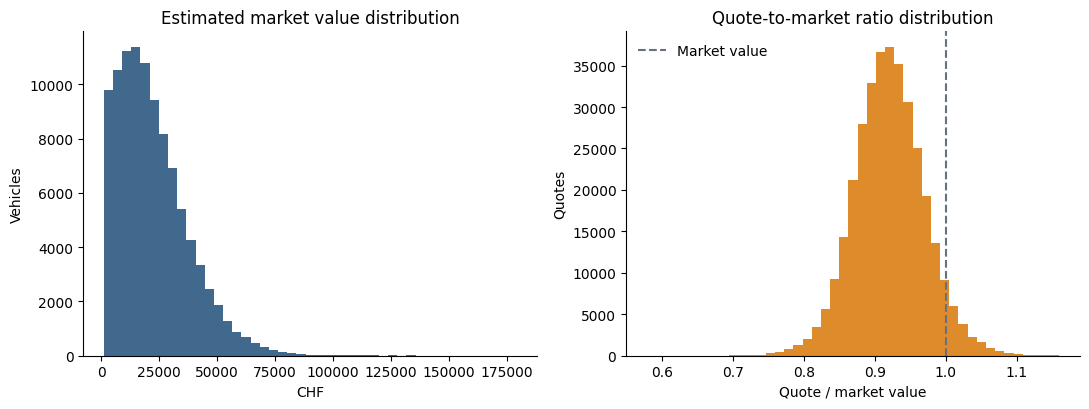

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(vehicles.estimated_market_value, bins=45, color=BLUE, alpha=0.85)
axes[0].set(title='Estimated market value distribution', xlabel='CHF', ylabel='Vehicles')
axes[1].hist(quotes.quote_to_market_ratio, bins=45, color=ORANGE, alpha=0.85)
axes[1].axvline(1.0, color=GREY, linestyle='--', label='Market value')
axes[1].set(title='Quote-to-market ratio distribution', xlabel='Quote / market value', ylabel='Quotes')
axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

### 4. Quotation spread increases in relative terms as vehicles age

In [5]:
age_labels = ['0-2 years', '3-5 years', '6-9 years', '10+ years']
age_analysis = (inquiries.assign(vehicle_age_band=pd.cut(inquiries.vehicle_age_at_inquiry, [-1, 2, 5, 9, np.inf], labels=age_labels))
    .groupby('vehicle_age_band', observed=True)
    .agg(inquiries=('inquiry_id', 'size'), average_spread_chf=('quote_spread', 'mean'), average_spread_pct=('quote_spread_pct', 'mean'))
    .reindex(age_labels))
age_analysis

,inquiries,average_spread_chf,average_spread_pct
vehicle_age_band,,,
0-2 years,27745,2671.951597,0.078974
3-5 years,34625,1894.428596,0.094621
6-9 years,24724,1201.975051,0.117576
10+ years,12719,562.319614,0.160529


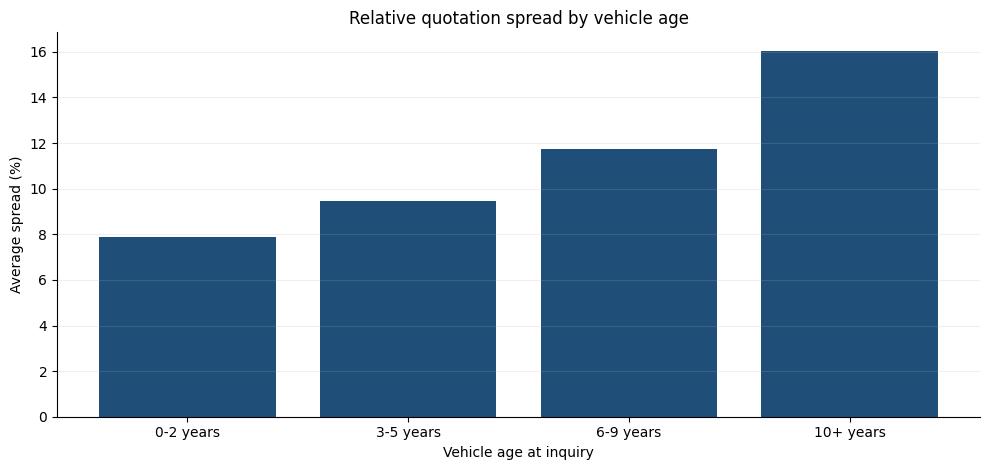

In [6]:
fig, axis = plt.subplots()
axis.bar(age_analysis.index, age_analysis.average_spread_pct * 100, color=BLUE)
axis.set(title='Relative quotation spread by vehicle age', ylabel='Average spread (%)', xlabel='Vehicle age at inquiry')
axis.grid(axis='y', alpha=0.2); plt.tight_layout(); plt.show()

### 5. Conversion varies materially by lead source

In [7]:
lead = (inquiries.groupby('lead_source').agg(inquiries=('inquiry_id', 'size'), conversions=('conversion_flag', 'sum'), conversion_rate=('conversion_flag', 'mean')).sort_values('conversion_rate'))
lead

,inquiries,conversions,conversion_rate
lead_source,,,
Social Media,11556,3098,0.268086
Paid Search,19110,5349,0.279906
Organic Search,26790,8765,0.327174
Direct,18171,6189,0.340598
Partner,7995,2841,0.355347
Dealer Referral,16191,6222,0.384288


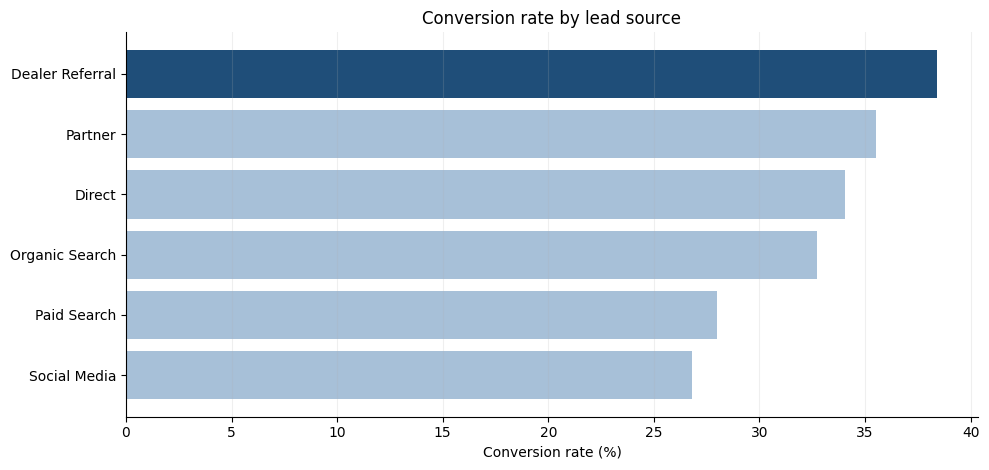

In [8]:
fig, axis = plt.subplots()
colors = [BLUE if value == lead.conversion_rate.max() else '#A7C0D8' for value in lead.conversion_rate]
axis.barh(lead.index, lead.conversion_rate * 100, color=colors)
axis.set(title='Conversion rate by lead source', xlabel='Conversion rate (%)', ylabel='')
axis.grid(axis='x', alpha=0.2); plt.tight_layout(); plt.show()

### 6. Dealer performance is differentiated by competitiveness

In [9]:
dealer_performance = (quotes.groupby('dealer_id').agg(quotes=('quote_id', 'size'), wins=('accepted_flag', 'sum'), win_rate=('accepted_flag', 'mean'), average_response_hours=('response_time_hours', 'mean'), quote_to_market_ratio=('quote_to_market_ratio', 'mean')).join(dealers.set_index('dealer_id')[['dealer_name', 'dealer_region']]))
dealer_performance.sort_values('win_rate', ascending=False).head(10)

,quotes,wins,win_rate,average_response_hours,quote_to_market_ratio,dealer_name,dealer_region
dealer_id,,,,,,,
D0111,2296,729,0.317509,6.171320,0.982825,Ticino Autohaus 111,Ticino
D0062,2273,668,0.293885,13.821232,1.000049,Central Autohaus 062,Central Switzerland
D0040,2302,601,0.261077,6.753614,0.976666,Eastern Autohaus 040,Eastern Switzerland
D0090,2294,557,0.242807,7.643784,0.982374,Eastern Autohaus 090,Eastern Switzerland
D0085,2254,541,0.240018,9.140102,0.982946,Ticino Autohaus 085,Ticino
D0126,2289,536,0.234163,14.751538,0.965980,Eastern Autohaus 126,Eastern Switzerland
D0134,2321,485,0.208962,17.160638,0.972024,Eastern Autohaus 134,Eastern Switzerland
D0076,2223,463,0.208277,11.005992,0.972781,Lake Autohaus 076,Lake Geneva
D0146,2240,449,0.200446,9.076388,0.954391,Lake Autohaus 146,Lake Geneva


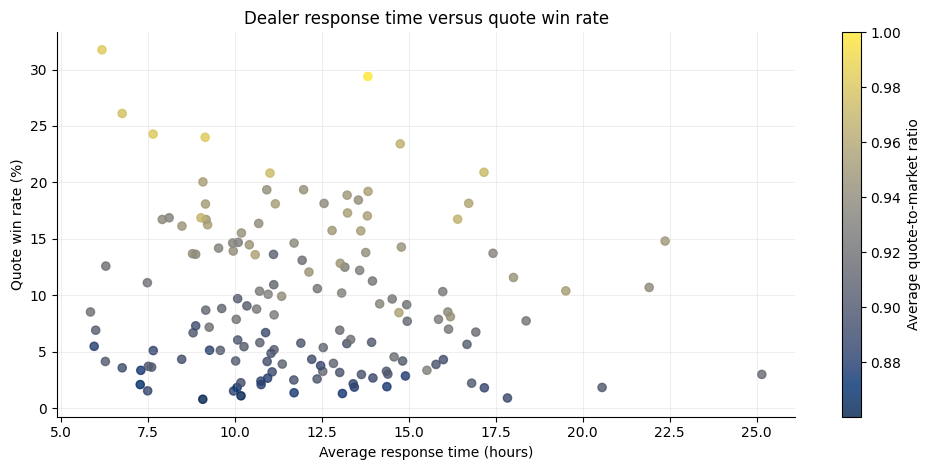

In [10]:
fig, axis = plt.subplots()
points = axis.scatter(dealer_performance.average_response_hours, dealer_performance.win_rate * 100, c=dealer_performance.quote_to_market_ratio, cmap='cividis', s=35, alpha=0.8)
axis.set(title='Dealer response time versus quote win rate', xlabel='Average response time (hours)', ylabel='Quote win rate (%)')
figure_colorbar = fig.colorbar(points, ax=axis); figure_colorbar.set_label('Average quote-to-market ratio')
axis.grid(alpha=0.2); plt.tight_layout(); plt.show()

### 7. Faster first responses are associated with higher inquiry conversion

In [11]:
response_labels = ['<4 hours', '4-8 hours', '8-16 hours', '16-24 hours', '24+ hours']
response = (inquiries.assign(response_band=pd.cut(inquiries.fastest_response_hours, [-.01, 4, 8, 16, 24, np.inf], labels=response_labels, right=False))
    .groupby('response_band', observed=True)
    .agg(inquiries=('inquiry_id', 'size'), conversion_rate=('conversion_flag', 'mean'))
    .reindex(response_labels))
response

,inquiries,conversion_rate
response_band,,
<4 hours,30532,0.340987
4-8 hours,49850,0.327663
8-16 hours,18137,0.296411
16-24 hours,1160,0.266379
24+ hours,134,0.253731


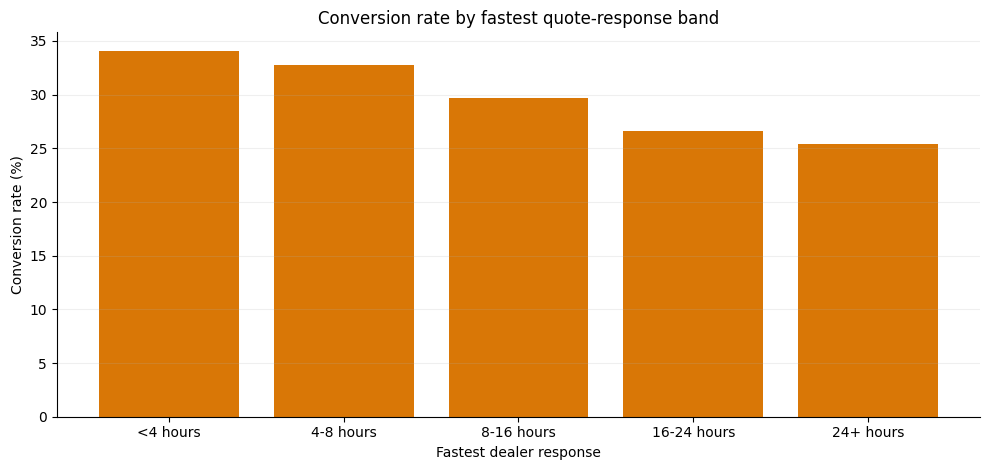

In [12]:
fig, axis = plt.subplots()
axis.bar(response.index, response.conversion_rate * 100, color=ORANGE)
axis.set(title='Conversion rate by fastest quote-response band', xlabel='Fastest dealer response', ylabel='Conversion rate (%)')
axis.grid(axis='y', alpha=0.2); plt.tight_layout(); plt.show()

### 8. Stability check: the headline comparisons are not driven by one year

The following tables repeat the response and channel comparisons within each calendar year. This does not establish causality, but it reduces the risk that the portfolio-level result is a simple time-mix artefact.

In [13]:
response_year = (inquiries.assign(year=inquiries.inquiry_date.dt.year, under_8h=inquiries.fastest_response_hours.lt(8))
    .groupby(['year', 'under_8h']).agg(inquiries=('inquiry_id', 'size'), conversions=('conversion_flag', 'sum'))
    .assign(conversion_rate=lambda frame: frame.conversions / frame.inquiries).reset_index())
response_pivot = response_year.pivot(index='year', columns='under_8h', values='conversion_rate').rename(columns={False: '8h_or_more', True: 'under_8h'})
response_pivot['lift_pp'] = (response_pivot.under_8h - response_pivot['8h_or_more']) * 100
response_pivot

under_8h,8h_or_more,under_8h,lift_pp
year,,,
2022,0.295353,0.332462,3.710942
2023,0.290648,0.332348,4.169993
2024,0.302175,0.334876,3.270084
2025,0.289343,0.331234,4.189123


In [14]:
channel_year = (inquiries.loc[inquiries.lead_source.isin(['Dealer Referral', 'Social Media'])]
    .assign(year=lambda frame: frame.inquiry_date.dt.year)
    .groupby(['year', 'lead_source']).conversion_flag.mean().unstack())
channel_year['referral_lift_pp'] = (channel_year['Dealer Referral'] - channel_year['Social Media']) * 100
channel_year

lead_source,Dealer Referral,Social Media,referral_lift_pp
year,,,
2022,0.386074,0.264730,12.134421
2023,0.386909,0.261459,12.545000
2024,0.390896,0.272698,11.819798
2025,0.374647,0.271719,10.292824


The under-eight-hour conversion lift remained positive in every year, ranging from **3.27 to 4.19 percentage points**. Dealer Referral also remained ahead of Social Media each year, by **10.29 to 12.54 percentage points**.

### 9. Correlation analysis at inquiry grain

In [15]:
correlation_fields = ['conversion_flag', 'fastest_response_hours', 'quote_spread_pct', 'quote_count', 'vehicle_age_at_inquiry']
correlations = inquiries[correlation_fields].corr()
correlations.round(3)

,conversion_flag,fastest_response_hours,quote_spread_pct,quote_count,vehicle_age_at_inquiry
conversion_flag,1.000,-0.040,0.047,0.050,0.016
fastest_response_hours,-0.040,1.000,-0.099,-0.260,-0.004
quote_spread_pct,0.047,-0.099,1.000,0.324,0.415
quote_count,0.050,-0.260,0.324,1.000,-0.002
vehicle_age_at_inquiry,0.016,-0.004,0.415,-0.002,1.000


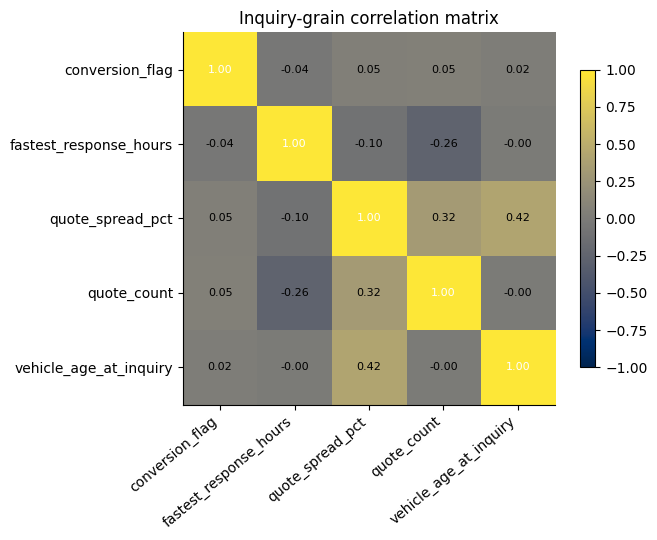

In [16]:
fig, axis = plt.subplots(figsize=(7, 5.5))
image = axis.imshow(correlations, cmap='cividis', vmin=-1, vmax=1)
axis.set_xticks(range(len(correlation_fields)), correlation_fields, rotation=40, ha='right')
axis.set_yticks(range(len(correlation_fields)), correlation_fields)
for row in range(len(correlation_fields)):
    for column in range(len(correlation_fields)):
        axis.text(column, row, f'{correlations.iloc[row, column]:.2f}', ha='center', va='center', color='white' if abs(correlations.iloc[row, column]) > .45 else 'black', fontsize=8)
axis.set_title('Inquiry-grain correlation matrix')
fig.colorbar(image, ax=axis, shrink=.8); plt.tight_layout(); plt.show()

### 10. Outlier and data-quality review

In [17]:
q1, q3 = quotes.quote_to_market_ratio.quantile([0.25, 0.75])
iqr = q3 - q1
iqr_outlier = ~quotes.quote_to_market_ratio.between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
pd.DataFrame({
    'check': ['Business-rule quote anomaly', 'IQR quote-ratio outlier'],
    'rows': [quotes.anomaly_flag.sum(), iqr_outlier.sum()],
    'rate': [quotes.anomaly_flag.mean(), iqr_outlier.mean()],
})

,check,rows,rate
0,Business-rule quote anomaly,1162,0.003387
1,IQR quote-ratio outlier,6026,0.017562


In [18]:
quality.assign(rate_percent=quality.rate * 100).sort_values(['stage', 'metric_name'])[['stage', 'metric_name', 'rate_percent']]

,stage,metric_name,rate_percent
0,Processed,completeness_rate,100.000000
1,Processed,overall_data_quality_score,100.000000
2,Processed,referential_integrity_rate,100.000000
3,Processed,uniqueness_rate,100.000000
4,Processed,validity_rate,100.000000
5,Raw,completeness_rate,99.974104
6,Raw,overall_data_quality_score,99.947442
7,Raw,referential_integrity_rate,99.960251
8,Raw,uniqueness_rate,99.879605
9,Raw,validity_rate,99.879148


## Takeaways

1. **Prioritize an eight-hour dealer response SLA.** Conversion was 33.27% below eight hours and 29.43% at eight hours or more.
2. **Protect high-quality referral capacity.** Dealer Referral outperformed Social Media by 11.62 percentage points.
3. **Use relative spread for older vehicles.** Vehicles aged 10+ years had 2.03x the relative quote dispersion of 0-2-year vehicles.
4. **Manage dealer competitiveness explicitly.** The dealer-level correlation between quote-to-market ratio and win rate was 0.90; this is descriptive, not causal.
5. **Keep anomaly review operational.** 1,162 curated positive quotes remain flagged, while hard-invalid rows are quarantined.